In [42]:
import pandas as pd
import numpy as np

import xarray as xr
import geopandas as gpd
import rioxarray as rxr
from shapely.geometry import mapping
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D
from plotnine import (ggplot, aes, geom_point, geom_vline, geom_hline,
                      geom_rect, scale_fill_manual, scale_color_manual,
                      scale_shape_manual, labs, theme_bw, theme, guides)


In [15]:
class DataLoader:
    ''' Class for loading climate data from differen sources and bring them in the desired format.
    For adding new methods: The result should be a xarray timeseries for your area of interest,
    for one scenario/model/variable combination.'''

    def crop_to_park_boundary(self, nc, boundary, variable):
        ''' Takes an xarray object and crops within the provided boundary (geopandas), returning a clipped xarray object. '''
        # Select just the variable (time_bnds doesn't have spatial dims)
        nc = nc[variable].rio.set_spatial_dims(x_dim="lon", y_dim="lat")
        nc = nc.rio.write_crs("EPSG:4326", inplace=True)
        if nc.rio.crs != boundary.crs:
            boundary = boundary.to_crs(nc.rio.crs)
        nc_clipped = nc.rio.clip(boundary.geometry.values, boundary.crs, drop=True, all_touched=True)

        return(nc_clipped)

    def load_isimip(self, scenario, model, variable, boundary):
        ''' Loads data from ISIMIP 3b. This data has alsoready been downloaded, and cropped to the area of interest,
        using bash and CDO. The scripts are in this repository. The data is founds in isimip/data/processed'''
        nc = xr.open_dataset(f'isimip/data/processed/{model}_w5e5_{scenario}_{variable}_jotr_monthly.nc', engine="netcdf4")
        nc_clipped = self.crop_to_park_boundary(nc, boundary, variable).mean(("lon", "lat"))

        return nc_clipped


In [ ]:
class ClimateFutures:
    ''' This class contains all the functions to create climate future datasets'''

    def __init__(self, models, scenarios, park, baseline_period):
        self.loader = DataLoader()
        self.models = models
        self.scenarios = scenarios
        self.park = park
        self.boundary = gpd.read_file(f'boundaries/{park}.shp')
        self.baseline_period = baseline_period

    def calculate_anomaly(self, scenario, baseline_period, model, variable, boundary):
        ''' Takes a clipped xarray object and calculates the anomaly relative to the provided baseline period. 
        Returns an xarray object of the anomaly. '''

        nc = self.loader.load_isimip(scenario, model, variable, boundary)
        nc_hist = self.loader.load_isimip("historical", model, variable, boundary)
        baseline = nc_hist.sel(time=slice(baseline_period[0], baseline_period[1])).mean("time")
        anomaly = nc - baseline

        return(anomaly)

    def plot_timeseries(self, ax, scenario, model, baseline_period, boundary, variable):

        if scenario == "historical":
            color = "blue"
        elif scenario == "ssp126":
            color = "#ffd580"  # light orange
        elif scenario == "ssp370":
            color = "#ff9900"  # dark orange
        elif scenario == "ssp585":
            color = "#e95462"  # red
        else:
            color = "gray"

        anomaly = self.calculate_anomaly(scenario, baseline_period, model, variable, boundary)
        anomaly_smooth = anomaly.rolling(time=36, center=True, min_periods=1).mean()
        plot = anomaly_smooth.plot(ax=ax, label=f"{model.split('_')[0]} {scenario}", color=color, alpha=1)

        return(plot)

    def plot_ensemble(self, variable):

        fig, ax = plt.subplots(figsize=(14, 6))

        for model in self.models:
            for scenario in self.scenarios:
                self.plot_timeseries(ax, scenario, model, self.baseline_period, self.boundary, variable)

        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.set_title(f'Anomaly (relative to 1979-2012) by Model and Scenario for {variable}')
        ax.set_ylabel('Anomaly')
        plt.tight_layout()
        plt.show()

    def mid_century_anomalies(self, scenario, baseline_period, model, variable, boundary):
        anomaly = self.calculate_anomaly(scenario, baseline_period, model, variable, boundary)
        mid_century_anomaly = anomaly.sel(time=slice("2035", "2065")).mean("time")

        return(mid_century_anomaly)

    def classify(self):
        all_data = []
        for model in self.models:
            for scenario in self.scenarios:
                if scenario == 'historical':
                    continue
                anomaly_tas = self.mid_century_anomalies(scenario, self.baseline_period, model, 'tas', self.boundary)
                anomaly_pr = self.mid_century_anomalies(scenario, self.baseline_period, model, 'pr', self.boundary)
                data = {
                    'model': model,
                    'scenario': scenario,
                    'park': self.park,
                    'anomaly_tas': anomaly_tas.item(),
                    'anomaly_pr': anomaly_pr.item()
                }
                all_data.append(data)

        df = pd.DataFrame(all_data)

        quantiles = df[['anomaly_tas', 'anomaly_pr']].quantile([0.25, 0.5, 0.75])

        conditions = [
            # warm-dry
            ((df['anomaly_tas'] < quantiles.loc[0.25, 'anomaly_tas']) & (df['anomaly_pr'] < quantiles.loc[0.50, 'anomaly_pr'])) |
            ((df['anomaly_tas'] < quantiles.loc[0.50, 'anomaly_tas']) & (df['anomaly_pr'] < quantiles.loc[0.25, 'anomaly_pr'])),
            # warm-wet
            ((df['anomaly_tas'] < quantiles.loc[0.25, 'anomaly_tas']) & (df['anomaly_pr'] > quantiles.loc[0.50, 'anomaly_pr'])) |
            ((df['anomaly_tas'] < quantiles.loc[0.50, 'anomaly_tas']) & (df['anomaly_pr'] > quantiles.loc[0.75, 'anomaly_pr'])),
            # hot-dry
            ((df['anomaly_tas'] > quantiles.loc[0.75, 'anomaly_tas']) & (df['anomaly_pr'] < quantiles.loc[0.50, 'anomaly_pr'])) |
            ((df['anomaly_tas'] > quantiles.loc[0.50, 'anomaly_tas']) & (df['anomaly_pr'] < quantiles.loc[0.25, 'anomaly_pr'])),
            # hot-wet
            ((df['anomaly_tas'] > quantiles.loc[0.75, 'anomaly_tas']) & (df['anomaly_pr'] > quantiles.loc[0.50, 'anomaly_pr'])) |
            ((df['anomaly_tas'] > quantiles.loc[0.50, 'anomaly_tas']) & (df['anomaly_pr'] > quantiles.loc[0.75, 'anomaly_pr']))
        ]

        future = ['warm-dry', 'warm-wet', 'hot-dry', 'hot-wet']

        df['climate_future'] = np.select(conditions, future, default='central')

        return df

    def _draw_scenario_points(self, ax, x, y, color, marker, scenario_idx):
        ''' Draw scatter points with fill style determined by scenario index:
            0 = filled, 1 = hollow, 2+ = double-ring (unfilled within unfilled) '''
        if scenario_idx == 0:
            ax.scatter(x, y, marker=marker, facecolor=color, edgecolor='k',
                       s=100, linewidth=1, zorder=3)
        elif scenario_idx == 1:
            ax.scatter(x, y, marker=marker, facecolor='none', edgecolor=color,
                       s=100, linewidth=2, zorder=3)
        else:
            # Double ring: large hollow outer + small hollow inner
            ax.scatter(x, y, marker=marker, facecolor='none', edgecolor=color,
                       s=180, linewidth=2, zorder=3)
            ax.scatter(x, y, marker=marker, facecolor='none', edgecolor=color,
                       s=55, linewidth=1.5, zorder=3)

    def plot_quadrants(self):
        future_colors = {
            'warm-dry': '#fea973',
            'warm-wet': '#e95462',
            'hot-dry': '#331067',
            'hot-wet': '#b5367a',
            'central': 'gray'
        }

        marker_pool = ['o', 's', '^', 'D', 'v', 'P', 'X']
        model_markers = {m: marker_pool[i % len(marker_pool)] for i, m in enumerate(self.models)}

        df = self.classify()
        scenarios = [s for s in self.scenarios if s != 'historical']
        quantiles = df[['anomaly_tas', 'anomaly_pr']].quantile([0.25, 0.5, 0.75])

        fig, ax = plt.subplots(figsize=(10, 8))

        # IQR box
        ax.add_patch(patches.Rectangle(
            (quantiles.loc[0.25, 'anomaly_tas'], quantiles.loc[0.25, 'anomaly_pr']),
            quantiles.loc[0.75, 'anomaly_tas'] - quantiles.loc[0.25, 'anomaly_tas'],
            quantiles.loc[0.75, 'anomaly_pr'] - quantiles.loc[0.25, 'anomaly_pr'],
            linewidth=2, edgecolor='gray', facecolor='none', linestyle='--'
        ))

        # Median lines
        ax.axvline(df['anomaly_tas'].median(), color='gray', linestyle='--', linewidth=1)
        ax.axhline(df['anomaly_pr'].median(), color='gray', linestyle='--', linewidth=1)

        # Plot points
        for model in self.models:
            marker = model_markers[model]
            for i, scenario in enumerate(scenarios):
                subset = df[(df['model'] == model) & (df['scenario'] == scenario)]
                if len(subset) == 0:
                    continue
                color = future_colors.get(subset['climate_future'].iloc[0], 'gray')
                self._draw_scenario_points(ax, subset['anomaly_tas'].values,
                                           subset['anomaly_pr'].values, color, marker, i)

        # Legend
        fill_labels = ['filled', 'hollow', 'double-ring']
        legend_elements = []

        # Models
        for model, marker in model_markers.items():
            legend_elements.append(Line2D([0], [0], marker=marker, color='w',
                                          markerfacecolor='gray', markeredgecolor='k',
                                          markersize=10, label=model.split('_')[0]))
        # Scenarios
        for i, scenario in enumerate(scenarios):
            style = fill_labels[min(i, len(fill_labels) - 1)]
            fc = 'gray' if i == 0 else 'none'
            ec = 'k' if i == 0 else 'gray'
            legend_elements.append(Line2D([0], [0], marker='o', color='w',
                                          markerfacecolor=fc, markeredgecolor=ec,
                                          markersize=10, label=f'{scenario} ({style})'))
        # Climate futures
        for future, color in future_colors.items():
            legend_elements.append(patches.Patch(facecolor=color, edgecolor='k', label=future))

        ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9)
        ax.set_xlabel('Temperature Anomaly (K)')
        ax.set_ylabel('Precipitation Anomaly (mm/day)')
        ax.set_title(f'Climate Futures for {self.park.upper()}')
        plt.tight_layout()
        plt.show()

    def plot_quadrants_plotnine(self):
        ''' Same quadrant plot as plot_quadrants() but implemented in plotnine.
        Scenario fill style is handled via separate geom_point layers:
          0 = filled (fill=climate_future color, black border)
          1 = hollow (no fill, colored border)
          2+ = double-ring (two hollow layers at different sizes)
        Plotnine's auto-legend is suppressed; a single combined matplotlib legend is built. '''

        future_colors = {
            'warm-dry': '#fea973',
            'warm-wet': '#e95462',
            'hot-dry': '#331067',
            'hot-wet': '#b5367a',
            'central': 'gray'
        }

        marker_pool = ['o', 's', '^', 'D', 'v', 'P', 'X']

        df = self.classify()
        df['model_short'] = df['model'].str.split('_').str[0]
        model_short_list = df['model_short'].unique().tolist()
        shape_map = {m: marker_pool[i % len(marker_pool)] for i, m in enumerate(model_short_list)}

        scenarios = [s for s in self.scenarios if s != 'historical']
        quantiles = df[['anomaly_tas', 'anomaly_pr']].quantile([0.25, 0.5, 0.75])

        iqr_box = pd.DataFrame({
            'xmin': [quantiles.loc[0.25, 'anomaly_tas']],
            'xmax': [quantiles.loc[0.75, 'anomaly_tas']],
            'ymin': [quantiles.loc[0.25, 'anomaly_pr']],
            'ymax': [quantiles.loc[0.75, 'anomaly_pr']]
        })

        # Base plot with reference lines and IQR box
        plot = (
            ggplot(df, aes(x='anomaly_tas', y='anomaly_pr'))
            + geom_rect(iqr_box, aes(xmin='xmin', xmax='xmax', ymin='ymin', ymax='ymax'),
                        fill='none', color='gray', linetype='dashed', size=0.8, inherit_aes=False)
            + geom_vline(xintercept=df['anomaly_tas'].median(), color='gray', linetype='dashed')
            + geom_hline(yintercept=df['anomaly_pr'].median(), color='gray', linetype='dashed')
        )

        # Add one geom_point layer per scenario to control fill style
        # Points are color-coded by climate future
        for i, scenario in enumerate(scenarios):
            subset = df[df['scenario'] == scenario].copy()
            if i == 0:
                # Filled: climate_future color fill, black border
                plot = plot + geom_point(
                    data=subset,
                    mapping=aes(x='anomaly_tas', y='anomaly_pr',
                                fill='climate_future', shape='model_short'),
                    color='black', size=4, stroke=0.8, inherit_aes=False
                )
            elif i == 1:
                # Hollow: no fill, colored border
                plot = plot + geom_point(
                    data=subset,
                    mapping=aes(x='anomaly_tas', y='anomaly_pr',
                                color='climate_future', shape='model_short'),
                    fill='none', size=4, stroke=1, inherit_aes=False
                )
            else:
                # Double-ring outer
                plot = plot + geom_point(
                    data=subset,
                    mapping=aes(x='anomaly_tas', y='anomaly_pr',
                                color='climate_future', shape='model_short'),
                    fill='none', size=4, stroke=0.8, inherit_aes=False
                )
                # Double-ring inner
                plot = plot + geom_point(
                    data=subset,
                    mapping=aes(x='anomaly_tas', y='anomaly_pr',
                                color='climate_future', shape='model_short'),
                    fill='none', size=1, stroke=0.8, inherit_aes=False
                )

        # Suppress plotnine's auto-legend; we'll build a clean matplotlib legend instead
        plot = (
            plot
            + scale_fill_manual(values=future_colors)
            + scale_color_manual(values=future_colors, guide=None)
            + scale_shape_manual(values=shape_map)
            + labs(x='Temperature Anomaly (K)', y='Precipitation Anomaly (mm/day)',
                   title=f'Climate Futures for {self.park.upper()}')
            + theme_bw()
            + theme(legend_position='none')
        )

        fig = plot.draw()
        ax = fig.axes[0]

        # Build a single combined matplotlib legend with section headers
        fill_labels = ['filled', 'hollow', 'double-ring']
        legend_handles = []

        # Climate Future section
        legend_handles.append(patches.Patch(facecolor='none', edgecolor='none',
                                            label='Climate Future'))
        for future, color in future_colors.items():
            legend_handles.append(patches.Patch(facecolor=color, edgecolor='k',
                                                label=f'  {future}'))

        # Model section
        legend_handles.append(patches.Patch(facecolor='none', edgecolor='none', label='Model'))
        for m, shape_char in shape_map.items():
            legend_handles.append(Line2D([0], [0], marker=shape_char, color='w',
                                         markerfacecolor='gray', markeredgecolor='k',
                                         markersize=8, label=f'  {m}'))

        # Scenario section
        legend_handles.append(patches.Patch(facecolor='none', edgecolor='none', label='Scenario'))
        for i, scenario in enumerate(scenarios):
            style = fill_labels[min(i, len(fill_labels) - 1)]
            fc = 'gray' if i == 0 else 'white'
            legend_handles.append(Line2D([0], [0], marker='o', color='w',
                                         markerfacecolor=fc, markeredgecolor='k',
                                         markersize=8, label=f'  {scenario} ({style})'))

        ax.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.02, 1),
                  fontsize=9, framealpha=1)

        return fig


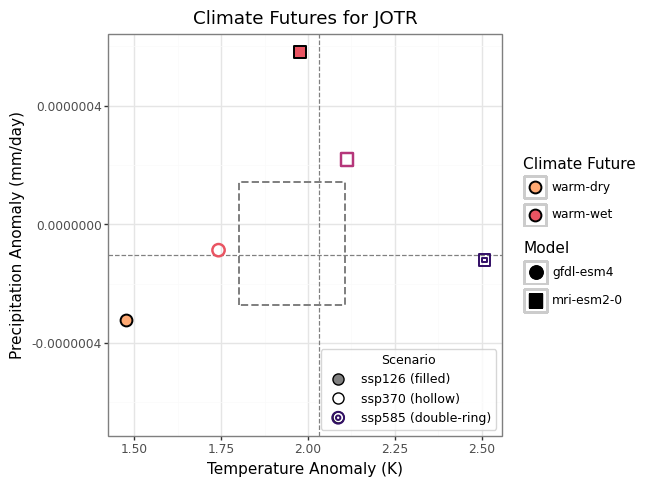

In [44]:
cf = ClimateFutures(
    models=['gfdl-esm4_r1i1p1f1', 'mri-esm2-0_r1i1p1f1'],
    scenarios=['ssp126', 'ssp370', 'ssp585', 'historical'],
    park='jotr',
    baseline_period=("1979", "2012")
)
cf.plot_quadrants_plotnine()
